## Çok sınıflı sınıflandırma (Multiclass classification)

* Önceki görevde ikili (binary) bir sınıflandırma problemini çözdük.  
* Peki ya **çok sınıflı (multiclass) bir sınıflandırma problemi**?

🎯 Egzersizin Amaçları:
- Çok sınıflı bir sınıflandırma problemi için tasarlanmış bir Sinir Ağı (Neural Network) yazmak
- Bu modelin ne kadar kolay **overfit** olabileceğini gözlemlemek… !

## (1) Bir `Blobs` veri kümesi oluşturun

📚 Sklearn’deki **`make_blobs`** fonksiyonu [(dokümantasyona bakınız)](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html) aşağıdakileri üretmenize olanak tanır:
- İstenilen sayıda veri örneği (`n_samples` parametresi)
- Her veri örneği için istenilen sayıda özellik (`n_features` parametresi)
- İstenilen sayıda sınıf/kategori (`centers` parametresi)
- Sınıflar arasındaki mesafe (`cluster_std` parametresi)

💡 Ayrıca, verinin **deterministik** olarak (aynı şekilde) üretilmesini ve tekrar edilebilir olmasını sağlayan `random_state` parametresi de vardır.


❓ Belgelere göre:

👽 Aşağıdakilerle bir ***blobs*** veri kümesi oluşturun:
- 1200 örnek
- Örnek başına 8 özellik
- 7 veri kategorisi
- Kategoriler arasındaki mesafe 8

🔮 1'e eşit bir `random_state` seçin.

📏 Şekli yazdırın ve `X` için (1200, 8) ve `y` için (1200,) ile eşleştiğini kontrol edin ❓

In [1]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=1200, n_features=8, centers=7, cluster_std=8, random_state=1)

print(X.shape)  # (1200, 8)
print(y.shape)  # (1200,)

(1200, 8)
(1200,)


❓ _matplotlib_ kullanarak bu blob veri kümesinin iki (rastgele) boyutunun dağılım grafiğini çizin. Her nokta, ait olduğu kategoriye göre renklendirilmelidir. ❓

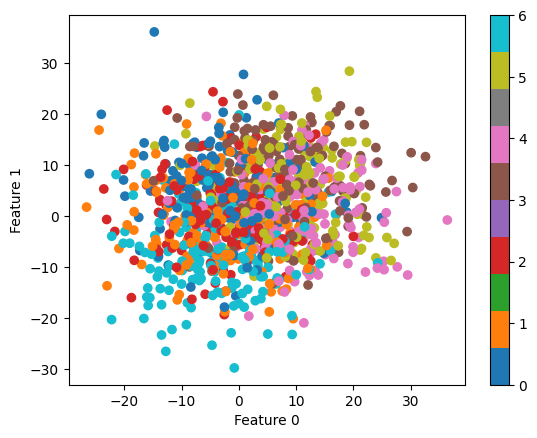

In [3]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='tab10')
plt.xlabel('Feature 0')
plt.ylabel('Feature 1')
plt.colorbar()
plt.show()

❓ Diğer boyutlarda da aynı işlemi tekrarlayın. Veri noktalarının kolayca ayrılmadığını görsel olarak görebilirsiniz ❓

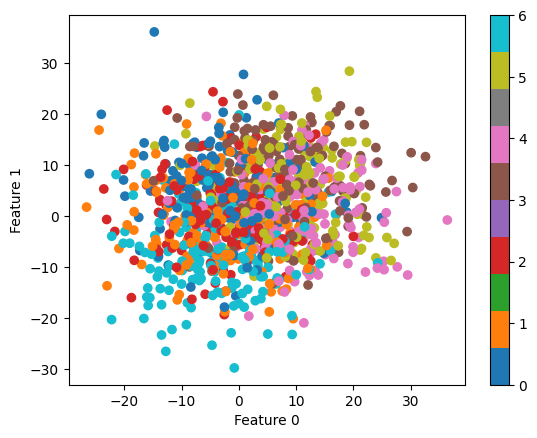

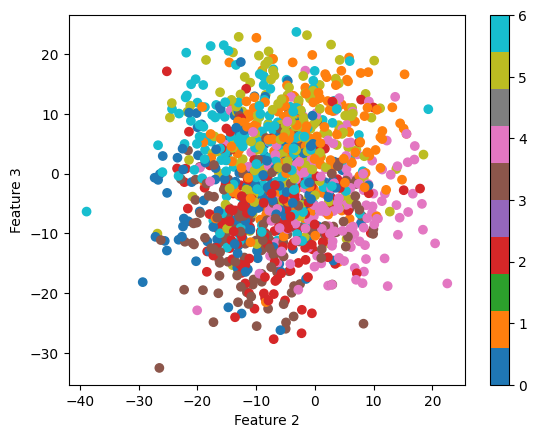

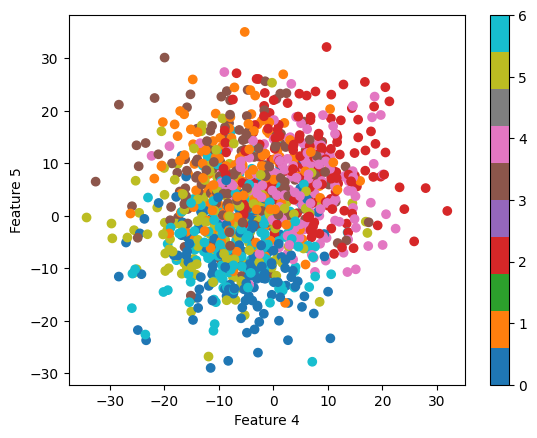

(1200, 7)


In [ ]:
for i in range(3):
    plt.scatter(X[:, i*2], X[:, i*2+1], c=y, cmap='tab10')
    plt.xlabel(f'Feature {i*2}')
    plt.ylabel(f'Feature {i*2+1}')
    plt.colorbar()
    plt.show()

    from tensorflow.keras.utils import to_categorical

y_cat = to_categorical(y, num_classes=7)
print(y_cat.shape)  # (1200, 7)

## (2) Çok sınıflı sınıflandırma probleminin hedefini kodlama

👉 Şu an için hedef `y`, giriş verisinin ait olduğu kategoriyi temsil eden **tamsayılar listesidir**. Şöyle görünür:  
`[3, 2, 2, 3, 0, 5, 1, 1, 0, 5, ...]`  
(bu örnekte 0’dan 6’ya kadar **7 kategori** vardır).

🧑🏻‍🏫 Ancak **Tensorflow/Keras’ta kategorik problemler için hedef/çıktı (`target/output`) aşağıdaki şekilde encode edilmelidir**:

```
[
[0, 0, 0, 1, 0, 0, 0], 
[0, 0, 1, 0, 0, 0, 0], 
[0, 0, 1, 0, 0, 0, 0], 
[1, 0, 0, 0, 0, 0, 0], 
[0, 0, 0, 0, 0, 1, 0], 
[0, 1, 0, 0, 0, 0, 0],
[0, 1, 0, 0, 0, 0, 0],
[1, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 1],
...
]
```


Burada:
- satır sayısı, **gözlem sayısına** eşittir  
- sütun sayısı, **farklı kategori sayısına** eşittir  

👉 Her sütun bir **kategoriyi** temsil eder.  

👉 Her satır bir **hedefi** temsil eder; `1` değeri, giriş verisinin ait olduğu kategoriyi gösterir.  

Bir satırı, olasılık vektörü olarak düşünebilirsiniz.

```
Örnek:
| Cat 0 | Cat 1 | Cat 2 | Cat 3 | Cat 4 | Cat 5 | Cat 6 |
|-------|-------|-------|-------|-------|-------|-------|
| 0     | 0     | 0     | 1     | 0     | 0     | 0     |

Bu, ilgili satırın %100 olasılıkla Cat 3’e ait olduğu anlamına gelir.
Cat 3
```


---

💡 `y`’yi kategorik hale dönüştürmek için **Tensorflow/Keras içindeki `to_categorical`** fonksiyonunu kullanın.

<details>
    <summary><i>Tensorflow/Keras’taki <code>to_categorical</code> ile Scikit-Learn’deki <code>OneHotEncoder</code> arasında bir benzerlik var mı?</i></summary>

Evet! **`to_categorical`**, Sklearn’deki `OneHotEncoder` gibi çalışır;  
ancak burada bir **kategorik feature** değil, **kategorik target (hedef)** encode edilir.

</details>

---

❓ **Kategorik hedefin kodlanması**:  `y` yazdırın, ardından *to_categorical* işlevini *`y`* üzerinde uygulayın ve *y'nin kategorize edilmiş halini* `y_cat` adlı bir değişkene kaydedin. ❓

In [5]:
print(y)

from tensorflow.keras.utils import to_categorical
y_cat = to_categorical(y, num_classes=7)
print(y_cat.shape)  # (1200, 7)

[2 2 5 ... 1 3 0]


2026-05-11 19:34:03.353765: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-11 19:34:03.358302: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-11 19:34:03.369798: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-11 19:34:03.422140: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-11 19:34:03.422220: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-11 19:34:03.455634: I tensorflow/core/platform/cpu_feature_guard.cc:

(1200, 7)


## (3) Çok Sınıflı Sınıflandırma Görevi için Sinir Ağı

❓ **Hold-out yöntemi**: Veri kümesi $X$ ve $y_{cat}$ 'i _train_ ve _test_ kümelerine ayırın (boyut: 70/30%)

Not: Değişkenleri `X_train`, `X_test`, `y_train` ve `y_test` olarak adlandırın ❓

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.3, random_state=1)

Derin Öğrenmede, herhangi bir Makine Öğrenimi algoritmasında olduğu gibi, sayısal özellikleriniz ölçeklendirilmelidir.

❓ **Ölçeklendirme**: Eğitim kümesine bir Sklearn [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) uydurun ve hem eğitim kümenizi hem de test kümenizi dönüştürün ❓

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

❓ **Modeli başlatma**: Aşağıdaki işlevi tamamlayarak aşağıdaki özelliklere sahip bir model oluşturun/başlatın:
- İlk katman:
   - 50 nöron
   - `relu` aktivasyonu
   - Doğru giriş boyutu
- Çıkış katmanı:
   - Çok sınıflı sınıflandırma görevi için tasarlanmış
   - Her sınıfa ait olma olasılıklarını çıktı olarak veren ❓

In [ ]:
from keras import Sequential, layers, Input

def initialize_model():
    model = Sequential()
    model.add(Input(shape=(8,)))
    model.add(layers.Dense(50, activation='relu'))
    model.add(layers.Dense(7, activation='softmax'))

    model.compile(loss='categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])
    return model

model = initialize_model()
model.summary()

2026-05-11 19:39:45.110390: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:09:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-11 19:39:45.111163: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │           450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           357 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 807 (3.15 KB)

 Trainable params: 807 (3.15 KB)

 Non-trainable params: 0 (0.00 B)

❓  Modelde kaç parametre (diğer adıyla ağırlık) vardır? ❓

In [ ]:
model = initialize_model()
model.summary()
# 8×50 + 50 = 450
# 50×7 + 7 = 357
# Toplam: 807

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 50)             │           450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           357 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 807 (3.15 KB)

 Trainable params: 807 (3.15 KB)

 Non-trainable params: 0 (0.00 B)

❓ **Modeli uydurma**: Modelinizi 50 dönemlik tren verilerine uydurun ve geçmişi çizin ❓

Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2202 - loss: 1.8935 - val_accuracy: 0.3528 - val_loss: 1.7497
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3726 - loss: 1.6596 - val_accuracy: 0.4667 - val_loss: 1.5674
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5036 - loss: 1.4845 - val_accuracy: 0.5444 - val_loss: 1.4274
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5619 - loss: 1.3433 - val_accuracy: 0.6028 - val_loss: 1.3076
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6179 - loss: 1.2252 - val_accuracy: 0.6500 - val_loss: 1.2124
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6548 - loss: 1.1280 - val_accuracy: 0.6611 - val_loss: 1.1336
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6714 - loss: 1.0474 - val_accuracy: 0.6722 - val_loss: 1.0745
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6917 - loss: 0.9819 - val_accuracy: 0.6694 - val_loss

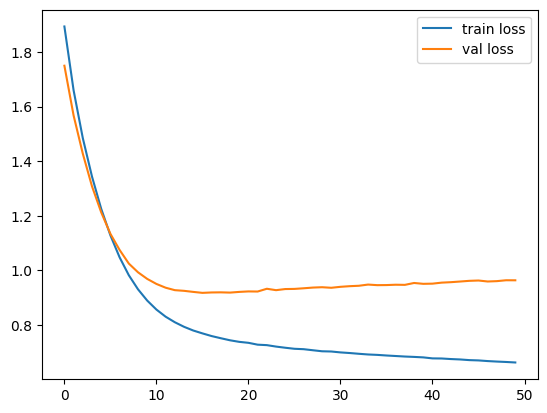

In [14]:
history = model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test))

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.show()

❓ **Değerlendirme**:  Modelinizi test setinde değerlendirin ve doğruluğu yazdırın ❓

In [15]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {accuracy:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6833 - loss: 0.9632 
Test accuracy: 0.6833


❓ 🤔 Bu iyi bir puan mı? Bunu bir tür karşılaştırma değeriyle karşılaştırmalısınız. Bu durumda, rastgele bir tahminle ne kadar puan elde edilebilir? Bu temel puanı `accuracy_baseline` değişkeninde saklayın. ❓

(Bunun için kod yazmanıza gerek yok, sadece veri setimizin nasıl oluşturulduğunu düşünün.)

In [16]:
accuracy_baseline = 1/7  # ≈ 0.143

🧪 **Kodunu Test Et**

In [17]:
from nbresult import ChallengeResult
result = ChallengeResult('baseline',
                         accuracy=accuracy_baseline)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/ubtuna/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/ubtuna/S-Data-multiclass-classification/tests
plugins: anyio-4.8.0, typeguard-4.4.2, dash-4.1.0
collecting ... collected 1 item

test_baseline.py::TestBaseline::test_accuracy PASSED                     [100%]

============================== 1 passed in 0.02s ===============================


💯 You can commit your code:

git add tests/baseline.pickle

git commit -m 'Completed baseline step'

git push origin master



❗ 👀 Bekle ... Kayıp grafiğine daha yakından bakarsan, 50 dönemden sonra da kayıp hala azalmaya devam ediyor gibi görünüyor. Neden bu kadar erken durduruyorsun ❓❗

❓ Modeli yeniden başlatıp bu sefer 1000 dönemle tekrar çalıştıralım ve geçmişi tekrar grafiğe çizelim. ❓

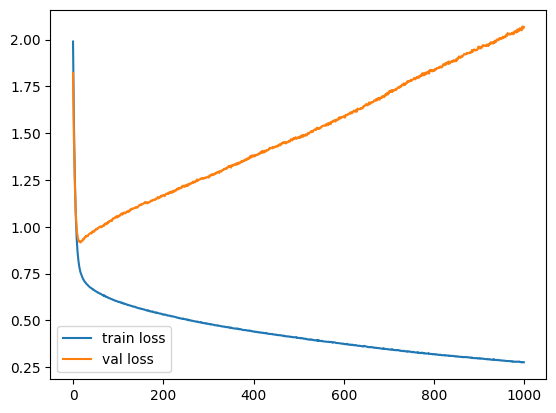

In [19]:
model = initialize_model()
history = model.fit(X_train, y_train, epochs=1000, validation_data=(X_test, y_test), verbose=0)

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.show()

❓ **Bir modeli daha uzun süre eğitirken...** ❓
- Yeni kayıp hakkında ne söyleyebilirsiniz?
- Modelinizi test setinde bir kez daha değerlendirin ve doğruluğu yazdırın.

In [20]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {accuracy:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6056 - loss: 2.0671 
Test accuracy: 0.6056


* 😁 Tren setinde hesaplanan kayıp, 50 epok ile karşılaştırıldığında 1000 epok ile daha küçük görünüyor.
* 😟 Anc ak test setindeki doğruluk, 50 epok ile karşılaştırıldığında 1000 epok ile daha kötü...

❓ Bu fenomene ne denir? ❓

Overfitting (Aşırı Öğrenme).
Train loss azalmaya devam ederken val_loss artmaya başlar.
Model eğitim verisini "ezberliyor", yeni veriye genelleyemiyor.

---

🤔 Bunun olmasını önlemek için ne yapmalıyız? 

<details>
    <summary><i>Olası seçenekler</i></summary>
    

⚠️ Sinir ağlarında aşırı uyumun olmasını önlemek için, örneğin şunları yapabiliriz:
1. Sinir ağının gürültülü veri noktalarından çok fazla öğrenmesini önlemek için ***makul sayıda dönem*** seçin
2. ***Erken Durdurma*** kriteri, yani _.fit()_ 📆 cf. ***Derin Öğrenme > Optimize Ediciler, Kayıp, Uydurma***

</details>    

---


❓ Test kaybının pratikte ne zaman tekrar artmaya başladığını görsel olarak kontrol edelim.  Aşağıdaki komutu çalıştırın ve geçmişi çizin❓

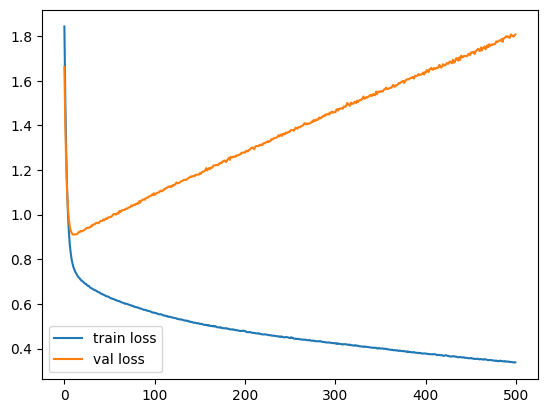

In [23]:
def plot_history(history):
    plt.plot(history.history['loss'], label='train loss')
    plt.plot(history.history['val_loss'], label='val loss')
    plt.legend()
    plt.show()

model = initialize_model()
history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=500,
                    batch_size=16,
                    verbose=0)
plot_history(history)

😱 Ama durun... test setini kullanırsak hile yapmış olmaz mıyız? Evet, oluruz. Ama yine sabırlı olun. ***Derin Öğrenme - Optimize Ediciler, Kayıp, Uydurma*** bölümünde, bunu önlemek için ***Doğrulama Seti*** adını verdiğimiz şeyi kullanacağız!

🧘🏻‍♀️ Şimdilik, sonraki sorulara geçelim!

❓ **Ağı değerlendirme**: <span style="color:blue">eğitim seti</span> ve <span style="color:orange">test seti</span> üzerindeki kayıp ve doğruluk değerlerini grafik olarak gösterin. Bu konuda ne söyleyebilirsiniz? ❓ 

In [25]:
def plot_loss_accuracy(history):
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'], loc='best')
    plt.show()

    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'], loc='best')
    plt.show()

In [ ]:
Train loss sürekli azalırken val_loss bir noktadan sonra artmaya başlıyor.
Train accuracy yükselirken val_accuracy düşüyor.
Bu klasik overfitting belirtisi: model eğitim verisini ezberliyor,
yeni veriye genelleyemiyor.
Sebep: ~800 parametre ile ~800 veri noktası → model/veri oranı çok yüksek.
Logistic Regression sadece 9 parametre ile aynı görevi yapabilirdi.

🤔 Derin Öğrenme modelimiz neden bu kadar kolay aşırı uyum sağlıyor?

😳 Düşünün, sinir ağımız sadece 8 özellik içeren bir veri kümesinden basit bir sınıflandırma görevi için ~800 parametre öğrenmek zorunda! Üstelik, uyum sağlamak için toplamda sadece ~800 veri noktamız var! Model, eğitim kümesindeki her noktanın tam sınıfını neredeyse “öğrenebilir”. 

Buna karşılık, basit bir Lojistik Regresyon, bu blob veri kümesinin kalıplarını yakalamak için sadece 9 parametreyi öğrenmek zorunda kalırdı! 

😏 Derin öğrenme etkileyici bir kavramdır, ancak basit makine öğrenimi görevleri için açıkça aşırı ve gereksiz bir seçenek olabilir!

⭐️ Aşağıdakiler için son derece yararlı olacaktır:
- 📸 Görüntü işleme
- 💹 Zaman serileri
- 🗣 Doğal dil işleme

---

🏁 Tebrikler!

💾 Not defterinizi `git add/commit/push` yapmayı unutmayın...

🚀 ... ve bir sonraki göreve geçin!